# 1. Introduction

In the data wrangling notes we took the BostonHousing2 data from a raw CSV file to a tidy `DataFrame`, visualized it, and fit an OLS baseline whose residuals showed clear nonlinear structure. These notes pick up from there and ask: *what model should capture that structure?*

With 506 observations, a feed-forward neural network is a poor match — deep learning is data-hungry, and on small-to-medium **tabular** data, tree-based ensembles remain the state of the art (Grinsztajn, Oyallon, and Varoquaux, 2022, ["Why do tree-based models still outperform deep learning on typical tabular data?"](https://arxiv.org/abs/2207.08815), *NeurIPS*). The workhorse of that family is **gradient boosting**, and its best-known implementation is **XGBoost**.

We work inside the **scikit-learn** ecosystem, the standard machine learning library for Python. Its great virtue is a *uniform interface*: every model — linear regression, decision tree, random forest — is an *estimator* with the same three methods (`fit()`, `predict()`, `score()`), and XGBoost deliberately implements the same interface. Learn the pattern once, and you can swap models with a single line.

We shall rely on the following modules:

*   `numpy` and `pandas` for data handling.
*   `scikit-learn` (imported as `sklearn`) for models, data splitting, cross-validation, metrics, and interpretation tools.
*   `xgboost` for gradient boosting.
*   `matplotlib.pyplot` for static graphics.
*   `plotly.express` for interactive graphics.
*   `shap` (optional) for state-of-the-art model interpretation.

The plan of attack mirrors how one should work in practice:

1.  Read and minimally prepare the data.
2.  Split into training and test sets.
3.  Fit a **linear baseline**, then climb the ladder of flexibility: a single **decision tree**, a **random forest**, and finally **XGBoost**.
4.  Tune XGBoost honestly with **cross-validation** and **early stopping**.
5.  **Interpret** the winning model: which features matter, and how?

# A Note on Colab versus a Local Installation

As before, this notebook is written for **Google Colab**, and the genuinely Colab-specific pieces are flagged with **⚠️ Colab-specific**. Colab preinstalls everything we use except `shap`. On a local installation you may first need, in a terminal:

```
pip install numpy pandas scikit-learn xgboost matplotlib plotly shap
```

Remember also from the wrangling notes: mounting Google Drive only exists on Colab (locally, use a plain file path); `display()` is Jupyter/IPython functionality (use `print()` in a plain script); and if a plotly figure comes up blank locally, `fig.show(renderer='browser')` opens it in a browser tab. No GPU is needed anywhere in this notebook — another practical advantage of tree ensembles over deep learning.

# 2. Reading and Preparing the Data

We read *BostonHousing2.csv* from Google Drive and repeat the wrangling steps from the previous notes in condensed form: tidy the column names, drop the redundant columns, promote the census tract to row index, and adopt the *corrected* median home value as our outcome `medv`.

**⚠️ Colab-specific:** the first two lines mount Google Drive; running the cell produces a pop-up asking you to authorize access. On a local installation, skip them and pass the file's location on your own disk to `pd.read_csv()`.

In [1]:
# --- Colab-specific: mount Google Drive (the google.colab module only exists on Colab)
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Teaching/BostonHousing2.csv')
# Local alternative: data = pd.read_csv('/Users/you/Documents/BostonHousing2.csv')

# Condensed wrangling (see the data wrangling notes for the full discussion)
data.columns = data.columns.str.lower().str.rstrip('.').str.replace('#', '_id')
data = data.drop(columns=['obs', 'town_id', 'medv'])
data = data.set_index('tract')
data = data.rename(columns={'cmedv': 'medv'})

data.head()

Mounted at /content/drive


,town,lon,lat,medv,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
tract,,,,,,,,,,,,,,,,,
2011,Nahant,-70.955,42.2550,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
2021,Swampscott,-70.950,42.2875,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2022,Swampscott,-70.936,42.2830,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
2031,Marblehead,-70.928,42.2930,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
2032,Marblehead,-70.922,42.2980,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


## 3. What We Do *Not* Need This Time

Recall the preparation a neural network demanded: log transforms for skewed features, standardization to mean 0 and variance 1, one-hot encoding. Trees need almost none of it, and it is worth understanding why.

A tree makes predictions by asking threshold questions — *is `crim` below 3.5?* — and such questions are unaffected by any order-preserving transformation. Log the crime rate, standardize it, square it: the same splits are available, and the tree will find them. Concretely:

*   **No scaling.** Trees are invariant to monotone transformations of the features, so standardization is unnecessary.
*   **No log transforms.** Skewness is harmless for the same reason.
*   **Less encoding.** An integer-coded categorical like `rad` can often be used as-is; the tree will carve it up as needed.
*   **Missing values.** XGBoost even handles `NaN`s natively: at every split it *learns* a default direction for missing observations. (Our data are complete, but this matters often in practice.)

What we absolutely still need is an **honest split of the data** — no model is exempt from that.

# 4. Splitting the Data

We hold out 20 percent of the tracts as a **test set**, touched only at the very end. Unlike the deep learning pipeline, we do not carve out a separate validation set up front: **cross-validation** on the training data will play that role when we tune (early stopping, later, will briefly need one). Fixing `random_state` makes the split reproducible.

We use the classic thirteen predictors, leaving the town name and the coordinates aside.

In [2]:
from sklearn.model_selection import train_test_split

features = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age',
            'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']

X = data[features]
y = data['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Training: {X_train.shape[0]} tracts")
print(f"Test:     {X_test.shape[0]} tracts")

Training: 404 tracts
Test:     102 tracts


# 5. The scikit-learn API and a Linear Baseline

Every scikit-learn estimator follows the same recipe:

```python
model = SomeEstimator(hyperparameters)   # 1. instantiate
model.fit(X_train, y_train)              # 2. learn from training data
model.predict(X_test)                    # 3. predict for new data
```

Because we will compare several models, we first write a small helper that evaluates any fitted model on the test set and stores three metrics:

*   **RMSE** (root mean squared error) — in the units of the outcome, here USD 1000s, and our primary criterion;
*   **MAE** (mean absolute error) — more robust to the occasional large miss;
*   **R²** — the share of variance explained, familiar from OLS.

Our baseline is linear regression. It is the same model as `statsmodels` OLS from the previous notes, but note the difference in spirit: `statsmodels` is built for *inference* (standard errors, t-tests), scikit-learn for *prediction* (no summary table, just predictions). A model this simple sets the bar any fancier method must clear.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

results = {}

def evaluate(model, name):
    """Evaluate a fitted model on the test set and store the results."""
    pred = model.predict(X_test)
    results[name] = {
        'RMSE': root_mean_squared_error(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred),
    }
    print(f"{name}:  RMSE = {results[name]['RMSE']:.2f}   "
          f"MAE = {results[name]['MAE']:.2f}   R2 = {results[name]['R2']:.3f}")

linear = LinearRegression()
linear.fit(X_train, y_train)
evaluate(linear, "Linear regression")

Linear regression:  RMSE = 4.95   MAE = 3.24   R2 = 0.667


# 6. A Single Regression Tree

A **regression tree** partitions the feature space by repeated threshold questions and predicts, within each final region (*leaf*), the mean outcome of the training observations that fall there. Trees are attractive because they are nonlinear, capture interactions automatically, and are easy to read — but a fully grown tree has a vice: it keeps splitting until it has effectively memorized the training data. Compare the training and test performance below; this gap is **overfitting** in its purest form.

In [4]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

print(f"R2 on the training data: {tree.score(X_train, y_train):.3f}")
print(f"R2 on the test data:     {tree.score(X_test, y_test):.3f}\n")

evaluate(tree, "Decision tree")

R2 on the training data: 1.000
R2 on the test data:     0.846

Decision tree:  RMSE = 3.37   MAE = 2.56   R2 = 0.846


To see how a tree thinks, we grow a deliberately shallow one. Even at depth 2 the story is sensible: the first and most important question concerns `rm` (house size), and within each branch `lstat` or further `rm` thresholds refine the prediction. Depth-2 trees like this one — too crude on their own — are exactly the *weak learners* that boosting will later stack by the hundreds.

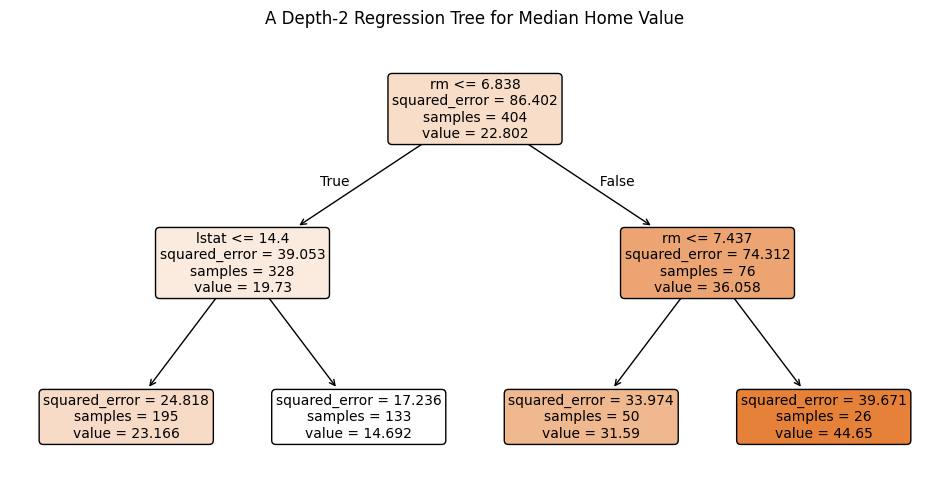

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

shallow = DecisionTreeRegressor(max_depth=2, random_state=42)
shallow.fit(X_train, y_train)

plt.figure(figsize=(12, 6))
plot_tree(shallow, feature_names=features, filled=True, rounded=True, fontsize=10)
plt.title("A Depth-2 Regression Tree for Median Home Value")
plt.show()

# 7. Random Forests: Wisdom of the Crowd

If one tree overfits, average many. A **random forest** grows hundreds of deep trees, each on a bootstrap sample of the training data and each considering only a random subset of features at every split, then averages their predictions. The randomness *decorrelates* the trees, and averaging decorrelated errors slashes variance — the ensemble is far more accurate than any of its members. This strategy of resampling-and-averaging is called **bagging** (bootstrap aggregating).

Note that the API is unchanged: instantiate, fit, evaluate.

In [6]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)

evaluate(forest, "Random forest")

Random forest:  RMSE = 2.98   MAE = 2.06   R2 = 0.880


# 8. Gradient Boosting and XGBoost

**Boosting** takes the opposite tack from bagging. Instead of many independent deep trees averaged at the end, it builds *shallow* trees **sequentially**, each one fit to the **residuals** — the errors — of the ensemble so far:

1.  Start with a constant prediction (the mean of `medv`).
2.  Fit a small tree to the current residuals.
3.  Add that tree's predictions to the ensemble, shrunk by a **learning rate** \(\eta\) (typically 0.01–0.3), so no single tree dominates.
4.  Repeat, hundreds or thousands of times.

Each tree therefore concentrates on exactly what its predecessors got wrong. "Gradient" refers to the general recipe: step 2 fits the tree to the negative gradient of the loss function, which for squared-error loss is precisely the residual.

**XGBoost** (extreme gradient boosting; Chen and Guestrin, 2016) is a fast, heavily engineered implementation that adds explicit regularization on tree complexity, row and column subsampling à la random forests, native missing-value handling, and clever histogram-based split finding. It has dominated tabular machine-learning competitions for a decade. Crucially for us, its `XGBRegressor` speaks fluent scikit-learn, so nothing about our workflow changes.

**⚠️ Colab-specific:** `xgboost` is preinstalled on Colab; on a local installation, `pip install xgboost` first.

We first fit it with its default hyperparameters.

In [7]:
from xgboost import XGBRegressor

xgb_default = XGBRegressor(random_state=42)
xgb_default.fit(X_train, y_train)

evaluate(xgb_default, "XGBoost (default)")

XGBoost (default):  RMSE = 2.85   MAE = 2.04   R2 = 0.890


# 9. Honest Tuning with Cross-Validation

Boosting is powerful but sensitive to its hyperparameters, chief among them:

| Hyperparameter | Role |
|---|---|
| `n_estimators` | number of trees (boosting rounds) |
| `learning_rate` | shrinkage per tree; lower = more careful, needs more trees |
| `max_depth` | depth of each tree; controls interaction order |
| `subsample` | fraction of rows sampled per tree |
| `colsample_bytree` | fraction of features sampled per tree |
| `reg_lambda` | L2 penalty on leaf values |

How do we choose them *without touching the test set*? **k-fold cross-validation**: split the *training* data into k folds (here five), train on four, validate on the fifth, rotate, and average. Every candidate configuration gets a validation score built from training data alone; the test set stays sealed. Using the test set to pick hyperparameters would be the tuning analogue of data leakage — the resulting "test" performance would flatter the model.

`GridSearchCV` wraps this whole procedure in — once again — a fit/predict interface. It tries every combination in the grid (here 3 × 3 × 2 = 18, times five folds = 90 fits; a few seconds on these data) and refits the best configuration on the full training set. For larger grids, `RandomizedSearchCV` samples configurations instead of exhausting them.

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300],
    'learning_rate': [0.03, 0.1, 0.3],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0],
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',   # sklearn maximizes, hence 'neg'
    n_jobs=-1)

grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")
print(f"Cross-validated RMSE: {-grid.best_score_:.2f}\n")

xgb_tuned = grid.best_estimator_
evaluate(xgb_tuned, "XGBoost (tuned)")

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Cross-validated RMSE: 3.36

XGBoost (tuned):  RMSE = 2.61   MAE = 1.86   R2 = 0.908


# 10. Early Stopping

One hyperparameter deserves special treatment: the number of trees. Rather than fixing it in advance, we can use **early stopping** — the same idea deep learning uses with epochs. Provide many more trees than needed, monitor the error on a validation set after every boosting round, and stop once it has not improved for (say) 50 rounds.

That validation set must come out of the *training* data — the test set stays sealed, as always. So we briefly carve off 20 percent of the training tracts. A common and effective pattern is to pair early stopping with a *small* learning rate: many careful steps, halted automatically at the right moment.

In [9]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42)

xgb_es = XGBRegressor(
    n_estimators=2000,               # an upper bound, not a commitment
    learning_rate=0.03,
    max_depth=grid.best_params_['max_depth'],
    subsample=grid.best_params_['subsample'],
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42)

xgb_es.fit(X_subtrain, y_subtrain,
           eval_set=[(X_subtrain, y_subtrain), (X_val, y_val)],
           verbose=False)

print(f"Boosting stopped after {xgb_es.best_iteration + 1} rounds\n")

evaluate(xgb_es, "XGBoost (early stopping)")

Boosting stopped after 981 rounds

XGBoost (early stopping):  RMSE = 2.86   MAE = 1.86   R2 = 0.889


The stored evaluation history lets us draw the **learning curve** — one of the most instructive plots in machine learning. Training error falls monotonically (more trees can only help *in sample*), while validation error falls, flattens, and eventually stops improving — beyond that point additional trees only fit noise. The dashed line marks the round early stopping selected. Hover to read off exact values; zoom into the elbow.

In [10]:
import plotly.express as px

history = xgb_es.evals_result()
curve = pd.DataFrame({
    'round': range(len(history['validation_0']['rmse'])),
    'training': history['validation_0']['rmse'],
    'validation': history['validation_1']['rmse'],
})

fig = px.line(curve, x='round', y=['training', 'validation'],
              title="XGBoost Learning Curve (Plotly)",
              labels={'round': 'Boosting Round', 'value': 'RMSE (USD 1000s)',
                      'variable': 'Data'})
fig.add_vline(x=xgb_es.best_iteration, line_dash='dash', line_color='gray',
              annotation_text='best iteration')

fig.show()

# 11. Which Model Wins?

We now open the sealed envelope and compare all models on the test set. (`display()` is Jupyter/IPython functionality; use `print()` in a plain script.)

In [11]:
comparison = pd.DataFrame(results).T.sort_values('RMSE')
display(comparison.round(3))

,RMSE,MAE,R2
XGBoost (tuned),2.605,1.865,0.908
XGBoost (default),2.852,2.035,0.890
XGBoost (early stopping),2.860,1.859,0.889
Random forest,2.981,2.061,0.880
Decision tree,3.368,2.556,0.846
Linear regression,4.952,3.244,0.667


The ranking tells the story of these notes. Even the single tree beats the linear model handily — the nonlinearity we diagnosed in the wrangling notes is real, and capturing it pays. But the tree's perfect training fit came at a price in variance, and the ensembles collect that debt: the random forest trims the RMSE further, and boosting further still, with the tuned XGBoost explaining roughly 90 percent of the test-set variance against two-thirds for the linear baseline. In dollars: the average prediction error has fallen from about \$5,000 to about \$2,600. The gap between the default and the tuned XGBoost is a reminder that hyperparameters are part of the model.

A caution: with only 102 test tracts, differences of a few tenths in RMSE are within noise. The robust conclusions are that flexible models beat the linear baseline and ensembles beat the single tree — not the precise ordering among the XGBoost variants.

# 11. Interpreting the Model

A tuned ensemble of hundreds of trees is not a formula one can read, but it is not a black box either — a small toolkit of interpretation methods, all part of the standard workflow, tells us which features drive the predictions and how.

## 11.1 Built-in Feature Importance

XGBoost reports, for each feature, its total contribution to reducing the loss across all splits (*gain*). This is computed for free during training, but has known quirks — it is calculated on training data and can spread credit arbitrarily among correlated features (recall `rad` and `tax` at r = 0.91) — so treat it as a first look.

In [12]:
importance = pd.Series(xgb_tuned.feature_importances_, index=features)
importance = importance.sort_values()

fig = px.bar(importance, orientation='h',
             title="XGBoost Feature Importance, Gain (Plotly)",
             labels={'index': 'Feature', 'value': 'Relative Importance'},
             color_discrete_sequence=['royalblue'])
fig.update_layout(showlegend=False)

fig.show()

## 11.2 Permutation Importance

A cleaner, model-agnostic alternative: shuffle one feature's values in the *test* data, breaking its relationship with the outcome, and record how much the model's R² drops. Features the model truly relies on cause large drops. Because shuffling is random, we repeat it 30 times and show the spread as error bars.

In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(xgb_tuned, X_test, y_test,
                              n_repeats=30, random_state=42, n_jobs=-1)

perm_imp = pd.DataFrame({'importance': perm.importances_mean,
                         'std': perm.importances_std}, index=features)
perm_imp = perm_imp.sort_values('importance')

fig = px.bar(perm_imp, x='importance', error_x='std', orientation='h',
             title="Permutation Importance on the Test Set (Plotly)",
             labels={'index': 'Feature', 'importance': 'Drop in R² when shuffled'},
             color_discrete_sequence=['royalblue'])

fig.show()

Both views agree on the headline: `lstat` and `rm` carry most of the predictive weight, echoing the correlation heatmap from the wrangling notes.

## 11.3 Partial Dependence: *How* Features Matter

Importance says *which*; **partial dependence** says *how*. For a grid of values of one feature, we set every tract's value to that level, average the model's predictions, and plot the curve. The nonlinearities we spotted with LOWESS in the wrangling notes reappear here — but now they are learned by the model rather than sketched by a smoother: home values fall steeply as `lstat` rises before flattening out, and rise sharply with `rm` only beyond about six and a half rooms.

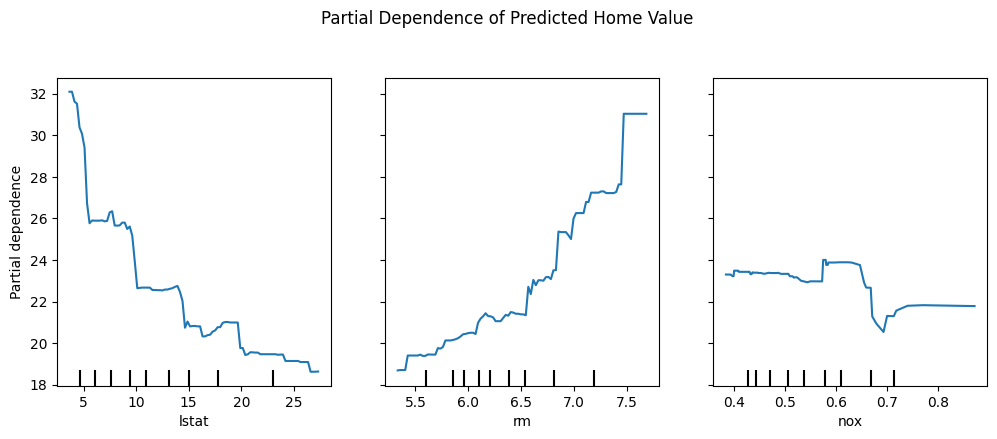

In [15]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    xgb_tuned, X_train, ['lstat', 'rm', 'nox'], ax=ax)

plt.suptitle("Partial Dependence of Predicted Home Value", y=1.05)
plt.show()

## 11.4 SHAP Values

The current state of the art in interpretation is **SHAP** (SHapley Additive exPlanations; Lundberg and Lee, 2017), which uses a concept from cooperative game theory to decompose *each individual prediction* into additive feature contributions. For tree ensembles this decomposition is exact and fast.

**⚠️ Colab-specific:** unlike everything above, `shap` is *not* preinstalled on Colab, so the next cell installs it first (the `%pip` magic works in Colab and Jupyter alike; in a terminal, drop the `%`).

In [16]:
%pip install shap --quiet

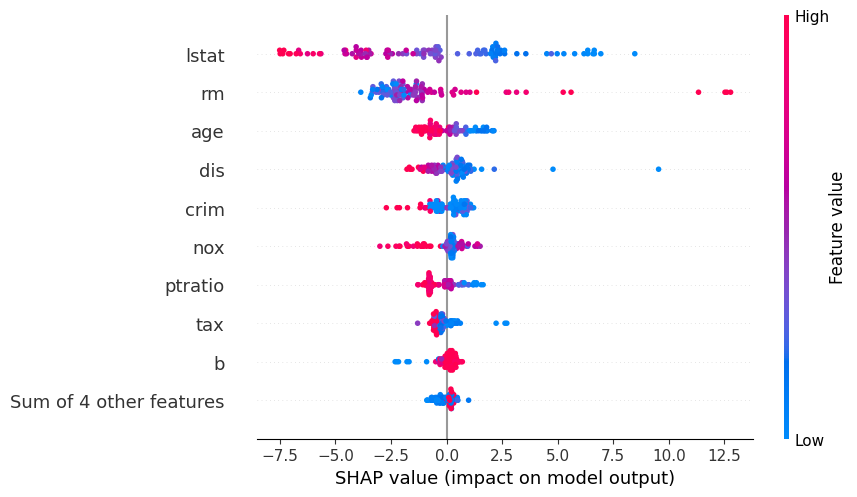

In [17]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer(X_test)

# Beeswarm: one dot per tract per feature; position = contribution to the
# prediction (in USD 1000s), color = the feature's value for that tract
shap.plots.beeswarm(shap_values)

Read the beeswarm as follows: for `lstat`, red dots (high values) sit far left — a high lower-status share pushes predicted values down by several thousand dollars — while blue dots sit right. The asymmetric tails show that extreme tracts move predictions much more than typical ones, something a single importance number hides.

A dependence plot for one feature shows the raw shape of its contribution, tract by tract, with the vertical scatter at each x-value revealing interactions with other features.

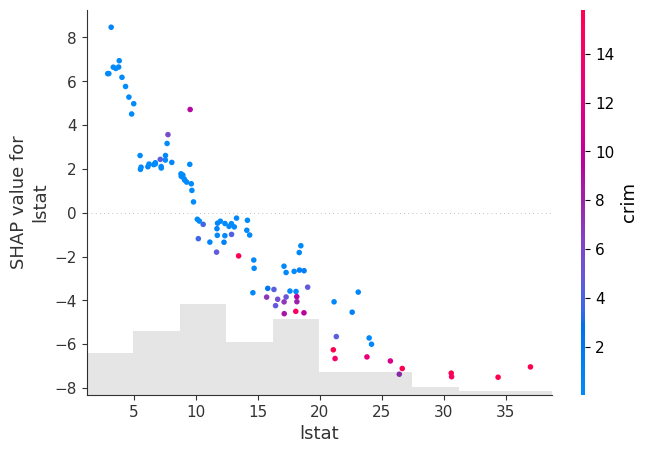

In [18]:
shap.plots.scatter(shap_values[:, 'lstat'], color=shap_values)

# 12. Wrapping Up

We climbed the full ladder from a linear baseline to a tuned gradient-boosting model, using one uniform API throughout. In summary:

1.  **Prepare lightly.** Trees are invariant to monotone transformations — no scaling, no log transforms, and XGBoost tolerates missing values natively. Honest data splitting remains non-negotiable.
2.  **Always fit a baseline.** Linear regression sets the bar; everything else must earn its complexity.
3.  **Single trees overfit; ensembles fix it** — random forests by averaging many decorrelated deep trees, boosting by sequentially correcting shallow ones. On these data, boosting wins.
4.  **Tune honestly.** Cross-validation chooses hyperparameters using training data only; early stopping chooses the number of trees; the test set is opened once.
5.  **Interpret.** Gain and permutation importance say *which* features matter; partial dependence and SHAP say *how*.

For tabular problems of this size, what you have just seen — XGBoost plus cross-validation plus SHAP — is not a stepping stone to deep learning; it *is* the state of the art. When we turn to neural networks in the coming weeks, it will be on the kinds of data where they genuinely dominate: images, text, and other high-dimensional inputs with far more observations. The BostonHousing2 results here give us a sobering benchmark to remember.